# Exploratory Data Analysis

This notebook focuses on exploratory data analysis across all three sources: CSV files, S3 and Snowflake. The goal is to understand the data before feature engineering and identify crucial relationships before modelling.

In [1]:
CSV_PATH = "../data/raw/csv/"

### Local CSV files

I will start the analysis by inspecting the CSV files. I will focus here on the missingness and distribution of numeric and descriptive data, as well as visualization of the customer's locations, competitors and POIs on the analysis area.

#### ds_locations

In [2]:
import pandas as pd
ds_locations = pd.read_csv(CSV_PATH + "ds_locations.csv")

In [3]:
ds_locations

,location_id,lat,lng,monthly_revenue
0,LOC_001,50.226272,19.072973,245633.74
1,LOC_002,50.299999,18.674625,333393.33
2,LOC_003,50.042894,19.968676,296109.69
3,LOC_004,50.130954,19.607709,197099.19
4,LOC_005,50.351594,18.894944,292786.56
5,LOC_006,50.016769,20.010290,174307.46
6,LOC_007,50.283699,19.017317,526630.01
7,LOC_008,50.147486,18.840116,156433.13
8,LOC_009,50.303099,18.678924,335019.41
9,LOC_010,50.347639,18.921651,355288.71


In [4]:
ds_locations.info()
ds_locations.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   location_id      50 non-null     object 
 1   lat              50 non-null     float64
 2   lng              50 non-null     float64
 3   monthly_revenue  50 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.7+ KB


,lat,lng,monthly_revenue
count,50.000000,50.000000,50.000000
mean,50.189476,19.301192,275269.401400
std,0.122854,0.521044,108052.296936
min,49.965208,18.548470,50000.000000
25%,50.096988,18.900723,204756.427500
50%,50.214888,19.061025,260956.905000
75%,50.287100,19.925615,318203.880000
max,50.441998,20.081011,623866.240000


In [5]:
print("Missing values in ds_locations:")
print(ds_locations.isnull().sum())

Missing values in ds_locations:
location_id        0
lat                0
lng                0
monthly_revenue    0
dtype: int64


In [6]:
import numpy as np

no_of_locations = ds_locations['location_id'].nunique()
total_monthly_revenue = np.sum(ds_locations['monthly_revenue'])
print(f"Number of unique locations: {no_of_locations}")
print(f"Total monthly revenue: {total_monthly_revenue.round(2)}")

Number of unique locations: 50
Total monthly revenue: 13763470.07


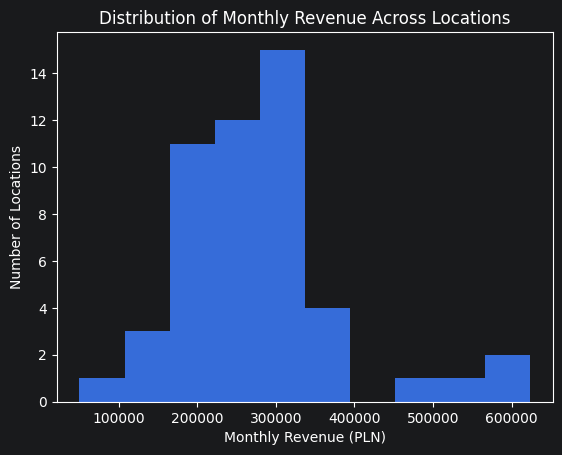

In [7]:
import matplotlib.pyplot as plt

plt.hist(ds_locations['monthly_revenue'], bins=10)
plt.xlabel('Monthly Revenue (PLN)')
plt.ylabel('Number of Locations')
plt.title('Distribution of Monthly Revenue Across Locations')
plt.show()

In [8]:
mean_revenue = ds_locations['monthly_revenue'].mean()
std_revenue = ds_locations['monthly_revenue'].std()

outliers = ds_locations[
    (ds_locations['monthly_revenue'] < mean_revenue - 2 * std_revenue) |
    (ds_locations['monthly_revenue'] > mean_revenue + 2 * std_revenue)
].copy()
outliers['deviation'] = ((outliers['monthly_revenue'] - mean_revenue) / std_revenue).round(2)

print(f"Mean: {mean_revenue:,.2f} | Std: {std_revenue:,.2f}")
print(f"Bounds: [{mean_revenue - 2 * std_revenue:,.2f}, {mean_revenue + 2 * std_revenue:,.2f}]")
print(f"\n{len(outliers)} outlier(s) found:")
outliers

Mean: 275,269.40 | Std: 108,052.30
Bounds: [59,164.81, 491,374.00]

4 outlier(s) found:


,location_id,lat,lng,monthly_revenue,deviation
6,LOC_007,50.283699,19.017317,526630.01,2.33
18,LOC_019,50.261991,19.026051,623866.24,3.23
32,LOC_033,50.280179,19.565872,50000.00,-2.08
42,LOC_043,50.253639,19.039906,573546.91,2.76


In [9]:
print(f"Skewness: {ds_locations['monthly_revenue'].skew():.2f}")
print(f"Kurtosis: {ds_locations['monthly_revenue'].kurt():.2f}")

Skewness: 1.15
Kurtosis: 2.42


Monthly Revenue Across Locations is right-skewed, which can be observed visually and via statistics. Such shape is typical for retail revenue data, where most stores cluster around average performance, while a smaller number of stores in prime locations generate a higher revenue.

 4 outliers were found. We will keep them: such revenue values, from 50k to 624k PLN per month, are realistic for grocery stores in Poland — from small local shops to larger stores in busy areas.
Revenue differences are important for our final model, because they may reflect real differences between locations that we aim to identify and explain.
The dataset has only about 50 locations, so removing 4 observations would mean losing around 8% of the data, which is quite significant.  

In [10]:
import geopandas as gpd

gdf_locations = gpd.GeoDataFrame(
    ds_locations,
    geometry=gpd.points_from_xy(ds_locations['lng'], ds_locations['lat']),
    crs="EPSG:4326"
)

Each dataframe will be immediately converted into GeoDataFrame for further visual analysis.

#### ds_competitors

In [11]:
ds_competitors = pd.read_csv(CSV_PATH + "ds_competitors.csv")

In [12]:
ds_competitors

,comp_id,brand,lat,lng
0,COMP_0001,Żabka,50.026907,20.048469
1,COMP_0002,Żabka,50.165093,18.882509
2,COMP_0003,Żabka,50.040923,19.923803
3,COMP_0004,Żabka,50.281506,19.146439
4,COMP_0005,Żabka,50.073621,20.025068
...,...,...,...,...
93,COMP_0094,Lewiatan,50.081776,19.999802
94,COMP_0095,Lewiatan,50.296087,19.478945
95,COMP_0096,Lewiatan,49.973710,18.946176
96,COMP_0097,Lewiatan,50.015953,19.950962


In [13]:
ds_competitors.info()
ds_competitors.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   comp_id  98 non-null     object 
 1   brand    98 non-null     object 
 2   lat      98 non-null     float64
 3   lng      98 non-null     float64
dtypes: float64(2), object(2)
memory usage: 3.2+ KB


,lat,lng
count,98.000000,98.000000
mean,50.180113,19.308845
std,0.124799,0.491663
min,49.972826,18.569767
25%,50.077520,18.910427
50%,50.164636,19.133913
75%,50.287737,19.921517
max,50.451751,20.106234


In [14]:
print("Missing values in ds_competitors:")
print(ds_competitors.isnull().sum())

Missing values in ds_competitors:
comp_id    0
brand      0
lat        0
lng        0
dtype: int64


In [15]:
total_no_of_competitor_locations = ds_competitors['comp_id'].nunique()
counts = ds_competitors['brand'].value_counts()
no_of_competitor_locations = pd.DataFrame({
    'brand': counts.index,
    'count': counts.values,
    'percentage': (counts.values / total_no_of_competitor_locations * 100).round(1)
})
print(f"Number of unique competitor locations: {total_no_of_competitor_locations}")
no_of_competitor_locations

Number of unique competitor locations: 98


,brand,count,percentage
0,Żabka,60,61.2
1,Lewiatan,13,13.3
2,Lidl,6,6.1
3,Dino,4,4.1
4,Carrefour,4,4.1
5,Netto,3,3.1
6,Stokrotka,3,3.1
7,Aldi,3,3.1
8,Kaufland,2,2.0


In [16]:
gdf_competitors = gpd.GeoDataFrame(
    ds_competitors,
    geometry=gpd.points_from_xy(ds_competitors['lng'], ds_competitors['lat']),
    crs="EPSG:4326"
)

#### ds_poi

In [17]:
ds_poi = pd.read_csv(CSV_PATH + "ds_poi.csv")

In [18]:
ds_poi

,poi_id,category,name,lat,lng
0,POI_0001,restaurant,Akira Sushi,50.444306,18.854625
1,POI_0002,restaurant,Za furtką,50.007247,20.012085
2,POI_0003,restaurant,Stodoła,50.060185,19.836112
3,POI_0004,restaurant,Dworek Białoprądnicki,50.092904,19.940781
4,POI_0005,restaurant,Pierwsze piętro,50.062469,19.935316
...,...,...,...,...,...
330,POI_0331,mall,Centrum Handlowe Żory,50.033993,18.683666
331,POI_0332,mall,Galeria PIK,50.167506,18.904237
332,POI_0333,mall,CHU Planeta,50.229642,18.663544
333,POI_0334,mall,Centrum Handlowe Max,50.141884,19.413357


In [19]:
ds_poi.info()
ds_poi.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335 entries, 0 to 334
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   poi_id    335 non-null    object 
 1   category  335 non-null    object 
 2   name      335 non-null    object 
 3   lat       335 non-null    float64
 4   lng       335 non-null    float64
dtypes: float64(2), object(3)
memory usage: 13.2+ KB


,lat,lng
count,335.000000,335.000000
mean,50.198706,19.286006
std,0.134370,0.488071
min,49.961147,18.546817
25%,50.071398,18.904120
50%,50.214649,19.134389
75%,50.304197,19.877788
max,50.478774,20.091541


In [20]:
print("Missing values in ds_poi:")
print(ds_poi.isnull().sum())

Missing values in ds_poi:
poi_id      0
category    0
name        0
lat         0
lng         0
dtype: int64


In [21]:
total_number_of_poi = ds_poi['poi_id'].nunique()
counts = ds_poi['category'].value_counts()
number_of_poi = pd.DataFrame({
    'category': counts.index,
    'count': counts.values,
    'percentage': (counts.values / total_number_of_poi * 100).round(1)
})
print(f"Number of unique points of interest: {total_number_of_poi}")
number_of_poi

Number of unique points of interest: 335


,category,count,percentage
0,restaurant,60,17.9
1,school,60,17.9
2,bus_stop,60,17.9
3,park,40,11.9
4,pharmacy,40,11.9
5,bank,30,9.0
6,hospital,30,9.0
7,mall,15,4.5


In [22]:
gdf_poi = gpd.GeoDataFrame(
    ds_poi,
    geometry=gpd.points_from_xy(ds_poi['lng'], ds_poi['lat']),
    crs="EPSG:4326"
)

#### ds_analysis_area

In [23]:
ds_analysis_area = pd.read_csv(CSV_PATH + "ds_analysis_area.csv")

In [24]:
ds_analysis_area

,area_name,geometry
0,Silesia-Kraków Metropolitan Area,"POLYGON ((18.540000 50.420000, 18.560000 50.45..."


In [25]:
ds_analysis_area.info()
ds_analysis_area.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   area_name  1 non-null      object
 1   geometry   1 non-null      object
dtypes: object(2)
memory usage: 144.0+ bytes


,area_name,geometry
count,1,1
unique,1,1
top,Silesia-Kraków Metropolitan Area,"POLYGON ((18.540000 50.420000, 18.560000 50.45..."
freq,1,1


In [26]:
from shapely import wkt

ds_analysis_area['geometry'] = ds_analysis_area['geometry'].apply(wkt.loads)
gdf_area = gpd.GeoDataFrame(ds_analysis_area, geometry='geometry', crs="EPSG:4326")

#### ds_districts

In [27]:
ds_districts = pd.read_csv(CSV_PATH + "ds_districts.csv")

In [28]:
ds_districts

,district_id,name,geometry
0,2401,Katowice,"POLYGON ((18.935000 50.256400, 18.924467 50.24..."
1,2402,Sosnowiec,"POLYGON ((19.061400 50.285867, 19.066667 50.27..."
2,2403,Gliwice,"POLYGON ((18.540000 50.282400, 18.540000 50.26..."
3,2404,Kraków,"POLYGON ((19.851400 50.057067, 19.840867 50.04..."
4,2405,Tychy,"POLYGON ((18.787533 50.114267, 18.798067 50.11..."
5,2406,Chrzanów,"POLYGON ((19.319467 50.128133, 19.314200 50.11..."
6,2407,Oświęcim,"POLYGON ((19.098267 50.020667, 19.093000 50.00..."
7,2408,Olkusz,"POLYGON ((19.419533 50.280667, 19.435333 50.26..."
8,2409,Rybnik,"POLYGON ((18.540000 50.102133, 18.540000 50.10..."
9,2410,Dąbrowa Górnicza,"POLYGON ((19.135133 50.329200, 19.140400 50.32..."


In [29]:
ds_districts.info()
ds_districts.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   district_id  15 non-null     int64 
 1   name         15 non-null     object
 2   geometry     15 non-null     object
dtypes: int64(1), object(2)
memory usage: 488.0+ bytes


,district_id
count,15.000000
mean,2408.000000
std,4.472136
min,2401.000000
25%,2404.500000
50%,2408.000000
75%,2411.500000
max,2415.000000


In [30]:
print("Missing values in ds_districts:")
print(ds_districts.isnull().sum())

Missing values in ds_districts:
district_id    0
name           0
geometry       0
dtype: int64


In [31]:
ds_districts['geometry'] = ds_districts['geometry'].apply(wkt.loads)
gdf_districts = gpd.GeoDataFrame(ds_districts, geometry='geometry', crs="EPSG:4326")

#### Bbox and visualization

In [32]:
analysis_area = gdf_area['geometry'].iloc[0]
bbox = analysis_area.bounds
print(f"Bbox of analysis area: {bbox}")
print(f"Longitude: {bbox[0]:.4f} - {bbox[2]:.4f}")
print(f"Latitude: {bbox[1]:.4f} - {bbox[3]:.4f}")

ANALYSIS_BBOX = {
    'lng_min': bbox[0],
    'lat_min': bbox[1],
    'lng_max': bbox[2],
    'lat_max': bbox[3]
}

Bbox of analysis area: (18.54, 49.96, 20.12, 50.48)
Longitude: 18.5400 - 20.1200
Latitude: 49.9600 - 50.4800


We identified the bbox of our analyzed area. It will be saved in a JSON format for reference.

In [33]:
import json
from pathlib import Path

path = Path("../data/processed/analysis_bbox.json")
path.parent.mkdir(parents=True, exist_ok=True)
with path.open('w') as f:
    json.dump(ANALYSIS_BBOX, f, indent=2)

Now, let's create a map.

In [34]:
import folium
from folium.plugins import MarkerCluster

def build_map(layers=None):
    centroid = analysis_area.centroid
    map = folium.Map(location=[centroid.y, centroid.x], zoom_start=10)

    if layers is None:
        layers = ['districts', 'locations', 'competitors', 'poi']

    folium.GeoJson(
        gdf_area,
        name='Analysis Area',
        style_function=lambda x: {'color': 'black', 'weight': 2, 'fillOpacity': 0.05}
    ).add_to(map)

    if 'districts' in layers:
        folium.GeoJson(
            gdf_districts,
            name='Districts',
            style_function=lambda x: {'color': 'black', 'weight': 1, 'fillOpacity': 0.05}
        ).add_to(map)

    if 'locations' in layers:
        group = folium.FeatureGroup(name='Locations')
        for _, row in gdf_locations.iterrows():
            folium.CircleMarker(
                location=[row['lat'], row['lng']],
                radius=6,
                color='red',
                fill=True,
                fillColor='red',
                popup=f"ID: {row['location_id']} \n Revenue: {row['monthly_revenue']:.0f} PLN"
            ).add_to(group)
        group.add_to(map)

    if 'competitors' in layers:
        group = folium.FeatureGroup(name='Competitors')
        for _, row in gdf_competitors.iterrows():
            folium.CircleMarker(
                location=[row['lat'], row['lng']],
                radius=6,
                color='blue',
                fill=True,
                fillColor='blue',
                popup=f"Brand: {row['brand']}"
            ).add_to(group)
        group.add_to(map)

    if 'poi' in layers:
        poi_cluster = MarkerCluster(name='POI')
        for _, row in gdf_poi.iterrows():
            folium.CircleMarker(
                location=[row['lat'], row['lng']],
                radius=6,
                color='green',
                fill=True,
                fillColor='green',
                popup=f"Category: {row['category']}"
            ).add_to(poi_cluster)
        poi_cluster.add_to(map)

    folium.LayerControl(collapsed=False).add_to(map)

    return map


In [35]:
map = build_map()

In [36]:
map

We can finally inspect the map with all plotted locations, competitors and POIs.
The analysis area covers the area of Krakow + Katowice urban area. Several client locations are outside the analysis area, but inside analyzed districts.

In [37]:
locations_inside = gdf_locations[gdf_locations.within(analysis_area)]
locations_outside = gdf_locations[~gdf_locations.within(analysis_area)]

print(f"Inside: {len(locations_inside)}")
print(f"Outside: {len(locations_outside)}")

if len(locations_outside) > 0:
    print("Locations outside the analysis area:")
    print(locations_outside)

Inside: 47
Outside: 3
Locations outside the analysis area:
   location_id        lat        lng  monthly_revenue  \
10     LOC_011  50.121043  18.548470        306718.03   
24     LOC_025  49.994134  20.053555        231470.22   
39     LOC_040  49.965208  18.956704        130489.86   

                     geometry  
10  POINT (18.54847 50.12104)  
24  POINT (20.05356 49.99413)  
39   POINT (18.9567 49.96521)  


Let's analyze the number of stores, competitors and POIs per district, as well as identify locations that are outside all district areas.

In [38]:
results = []

for _, district in gdf_districts.iterrows():
    district_geometry = district['geometry']

    client_locations = gdf_locations[gdf_locations.within(district_geometry)]
    competitor_locations = gdf_competitors[gdf_competitors.within(district_geometry)]
    pois = gdf_poi[gdf_poi.within(district_geometry)]

    results.append({
        'district_id': district['district_id'],
        'name': district['name'],
        'client_locations': len(client_locations),
        'competitor_locations': len(competitor_locations),
        'poi_count': len(pois)
    })

all_districts_union = gdf_districts['geometry'].union_all()
results.append({
    'district_id': None,
    'name': 'None',
    'client_locations': len(gdf_locations[~gdf_locations.within(all_districts_union)]),
    'competitor_locations': len(gdf_competitors[~gdf_competitors.within(all_districts_union)]),
    'poi_count': len(gdf_poi[~gdf_poi.within(all_districts_union)])
})

summary_per_district = pd.DataFrame(results)
summary_per_district

,district_id,name,client_locations,competitor_locations,poi_count
0,2401.0,Katowice,7,9,28
1,2402.0,Sosnowiec,3,5,24
2,2403.0,Gliwice,7,8,39
3,2404.0,Kraków,14,27,72
4,2405.0,Tychy,2,7,13
5,2406.0,Chrzanów,1,3,19
6,2407.0,Oświęcim,0,4,8
7,2408.0,Olkusz,2,5,11
8,2409.0,Rybnik,1,5,17
9,2410.0,Dąbrowa Górnicza,1,3,16


Notably, there are two stores not found in the analysis area. Let's identify them.

In [39]:
unassigned_locations = gdf_locations[~gdf_locations.within(all_districts_union)]
print("Locations not assigned to any district:")
print(unassigned_locations[['location_id', 'lat', 'lng', 'monthly_revenue']])

Locations not assigned to any district:
   location_id        lat        lng  monthly_revenue
37     LOC_038  50.189307  18.622520        121446.26
45     LOC_046  50.258876  18.934631        220894.99


These two locations are at the intersection of two districts - we can see that the map displays the rifts between districts. We can assert optically that all POIs and competitor locations are inside the districts.
We previously identified 3 locations that are outside our analysed area. Now we can see that they are still inside the district areas. We can calculate the distance of those three locations from the boundary of the analysed area.

In [40]:
gdf_outside_proj = locations_outside.to_crs('EPSG:2180')
analysis_proj = gpd.GeoSeries([analysis_area], crs='EPSG:4326').to_crs('EPSG:2180').iloc[0]

for idx, row in gdf_outside_proj.iterrows():
    distance_m = row.geometry.distance(analysis_proj.boundary)
    print(f"Location {row['location_id']}: {distance_m:.0f} meters from boundary, revenue {row['monthly_revenue']:.0f} PLN")

Location LOC_011: 1833 meters from boundary, revenue 306718 PLN
Location LOC_025: 895 meters from boundary, revenue 231470 PLN
Location LOC_040: 1442 meters from boundary, revenue 130490 PLN


Revenue and location outliers do not overlap, which is a

The locations are not far from the analyzed area. Let's verify the coverage of the analyzed area and the district areas:

In [41]:
districts_union = gdf_districts.geometry.union_all()

extra_area = districts_union.difference(analysis_area)
print(f"Districts area: {districts_union.area}")
print(f"Analysis area: {analysis_area.area}")
print(f"Districts NOT covered by analysis_area: {extra_area.area}")
print(f"Districts are {(districts_union.area - analysis_area.area) / analysis_area.area:.1%} larger than analysis area")
print(f"{extra_area.area / districts_union.area:.1%} of districts area lies outside analysis area")

Districts area: 0.8088422615569948
Analysis area: 0.7026500000000007
Districts NOT covered by analysis_area: 0.11746539944956455
Districts are 15.1% larger than analysis area
14.5% of districts area lies outside analysis area


The analysis area is a strict subset of the union of districts — ~13% of the districts' area lies outside `analysis_area`, including the 3 client locations identified earlier.

This discrepancy is intentional. Analysis area defines the scope for whitespot search, i.e. where the client wants to expand. The goal of the project is to also build a model that would predict the sales potential of a given location, where all existing locations are needed.

All client locations will be used to develop a model, including those located outside the analysis area. The whitespot analysis, however, will only be conducted for the analysis area, as per the client's brief.

We previously identified 4 revenue outliers, with ids: `007`, `019`, `033`, `043`. We can now inspect their locations:
- ID `007` - Wełnowiec-Józefowiec, nothern district of Katowice
- ID `019` - Katowice Śródmieście
- ID `033` - Olkusz
- ID `043` - Katowice Śródmieście

As expected, the stores with monthly revenue more than two standard deviations higher than the mean are located in / near the city center of Katowice, while the stores with lower revenue are located in areas far from any larger city of the region.

District union area will also be saved for reference.

In [120]:
districts_bbox = gdf_districts.total_bounds

DISTRICTS_BBOX = {
    'lng_min': districts_bbox[0],
    'lat_min': districts_bbox[1],
    'lng_max': districts_bbox[2],
    'lat_max': districts_bbox[3]
}

DISTRICTS_BBOX

{'lng_min': np.float64(18.54),
 'lat_min': np.float64(49.96),
 'lng_max': np.float64(20.12),
 'lat_max': np.float64(50.48)}

It turns out that the district bounds are exactly the same as bounds for analysis area - so they will not be saved.

### AWS S3 Data

In [44]:
from src.connectors import get_s3_client
from dotenv import load_dotenv
import os

s3 = get_s3_client()
load_dotenv()

True

In [45]:
response = s3.list_objects_v2(Bucket=os.environ["AWS_BUCKET"])
for obj in response.get('Contents', []):
    print(obj['Key'], obj['Size'])

DATA_ENGINEER/ 0
DATA_ENGINEER/recruitment_buildings.csv.gz 204115254
DATA_ENGINEER/recruitment_population.csv.gz 20827012


In [46]:
bucket = os.environ["AWS_BUCKET"]
for ds in ["recruitment_buildings.csv.gz", "recruitment_population.csv.gz"]:
    local_path  = Path("../data/raw/s3") / ds
    key = "DATA_ENGINEER/" + ds
    local_path.parent.mkdir(parents=True, exist_ok=True)

    if local_path.exists():
        print(f"Already downloaded: {ds}")
    else:
        print(f"Downloading {ds}...")
        s3.download_file(bucket, key, str(local_path))
        print(f"Done: {local_path}")

Already downloaded: recruitment_buildings.csv.gz
Already downloaded: recruitment_population.csv.gz


In [47]:
df_buildings = pd.read_csv("../data/raw/s3/recruitment_buildings.csv.gz", compression="gzip")
df_population = pd.read_csv("../data/raw/s3/recruitment_population.csv.gz", compression="gzip")

#### df_buildings

In [48]:
df_buildings.head()

,teryt,lokalnyid,funogolnabudynku_desc,funszczegolowabudynku_desc,area,geometry,geojson,geohash5
0,1213,2F4C2F62-184E-145C-E053-CC2BA8C0A22F,budynkiMieszkalneJednorodzinne,"[\n ""budynekJednorodzinny""\n]",75.61,POLYGON ((19.1498510264998352 50.0308856683515...,"{""type"": ""Polygon"", ""coordinates"": [[[19.14985...",u2vse
1,1213,2F4C2F62-12D2-145C-E053-CC2BA8C0A22F,budynkiLacznosciDworcowITerminali,"[\n ""budynekKontroliRuchuKolejowego""\n]",90.42,POLYGON ((19.1800013310724964 50.0148159656261...,"{""type"": ""Polygon"", ""coordinates"": [[[19.18000...",u2vss
2,1213,2F4C2F62-12D3-145C-E053-CC2BA8C0A22F,budynkiODwochMieszkaniach,"[\n ""budynekODwochMieszkaniach""\n]",147.94,POLYGON ((19.1859326432092487 50.0085967015947...,"{""type"": ""Polygon"", ""coordinates"": [[[19.18593...",u2vsk
3,1213,2F4C2F61-6B19-145C-E053-CC2BA8C0A22F,budynkiMieszkalneJednorodzinne,"[\n ""budynekJednorodzinny""\n]",135.85,POLYGON ((19.3497051673450216 49.9951855359036...,"{""type"": ""Polygon"", ""coordinates"": [[[19.34970...",u2vu2
4,1213,2F4C2F61-59F2-145C-E053-CC2BA8C0A22F,budynekGospodarstwaRolnego,"[\n ""budynekGospodarczy""\n]",291.99,POLYGON ((19.2838162170323280 50.0361924729283...,"{""type"": ""Polygon"", ""coordinates"": [[[19.28381...",u2vsw


In [49]:
df_buildings.info()
df_buildings.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 955612 entries, 0 to 955611
Data columns (total 8 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   teryt                       955612 non-null  int64  
 1   lokalnyid                   955612 non-null  object 
 2   funogolnabudynku_desc       955612 non-null  object 
 3   funszczegolowabudynku_desc  955612 non-null  object 
 4   area                        955612 non-null  float64
 5   geometry                    955612 non-null  object 
 6   geojson                     955612 non-null  object 
 7   geohash5                    955612 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 58.3+ MB


,teryt,area
count,955612.000000,955612.000000
mean,1937.070181,172.835219
std,602.398226,774.083697
min,1203.000000,0.110000
25%,1212.000000,71.280000
50%,2405.000000,104.940000
75%,2466.000000,144.470000
max,2479.000000,168237.790000


In [50]:
print("Missing values in df_buildings:")
print(df_buildings.isnull().sum())

Missing values in df_buildings:
teryt                         0
lokalnyid                     0
funogolnabudynku_desc         0
funszczegolowabudynku_desc    0
area                          0
geometry                      0
geojson                       0
geohash5                      0
dtype: int64


In [51]:
df_buildings['geometry'] = df_buildings['geometry'].apply(wkt.loads)
gdf_buildings = gpd.GeoDataFrame(df_buildings, geometry='geometry', crs="EPSG:4326")

In [71]:
gdf_buildings_area = gdf_buildings.cx[
    districts_bbox[0]:districts_bbox[2],
    districts_bbox[1]:districts_bbox[3]
]
print(f"Buildings NOT in districts bbox: {len(df_buildings) - len(gdf_buildings_area)}")

Buildings NOT in districts bbox: 0


The dataset is already scoped to the analysis region - no filtering required.

In [53]:
total_no_of_buildings = df_buildings['lokalnyid'].nunique()
no_of_buildings = df_buildings['funogolnabudynku_desc'].value_counts()
no_of_detailed_buildings = df_buildings['funszczegolowabudynku_desc'].value_counts()
print(f"Number of unique buildings: {total_no_of_buildings}")
print(f"Number of buildings per category: {no_of_buildings}")
print(f"Number of buildings per detailed category: {no_of_detailed_buildings}")

Number of unique buildings: 955612
Number of buildings per category: funogolnabudynku_desc
budynkiMieszkalneJednorodzinne                 453932
budynekGospodarstwaRolnego                     289208
budynkiOTrzechIWiecejMieszkaniach               65376
budynkiODwochMieszkaniach                       33738
budynkiGarazy                                   25812
budynkiHandlowoUslugowe                         23157
budynkiPrzemyslowe                              18989
zbiornikSilosIBudynkiMagazynowe                 12841
budynkiBiurowe                                  12410
budynkiSzkolIInstytucjiBadawczych                5138
budynkiHoteli                                    2783
budynkiSzpitaliIZakladowOpiekiMedycznej          2416
budynkiZbiorowegoZamieszkania                    2157
pozostaleBudynkiNiemieszkalne                    2152
budynkiKultuReligijnego                          1611
budynkiMuzeowIBibliotek                           987
ogolnodostepneObiektyKulturalne              

The `funszczegolowabudynku_desc` column stores values as JSON arrays, suggesting a single building can have multiple detailed functions. This will need to be parsed during feature engineering.

Area:
  negative values: 0
  maximum value: 168237.79
area
[200, 300)         55253
[300, 500)         35418
[500, 1000)        24331
[1000, 5000)       12683
[5000, 10000)        755
[10000, 168238)      631
Name: count, dtype: int64


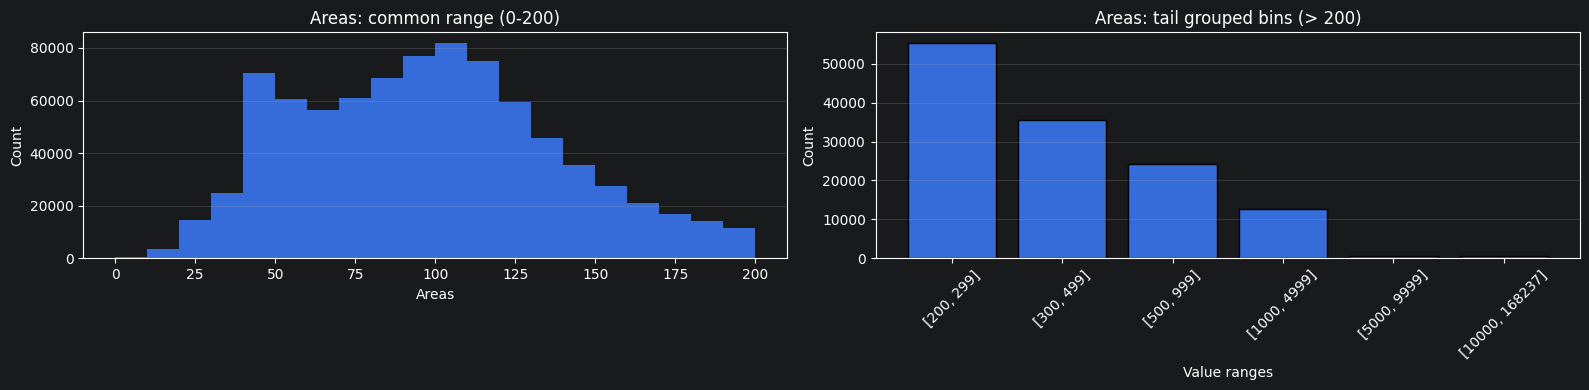

In [54]:
areas = df_buildings['area']
cutoff = 200

negative_count = (areas < 0).sum()
max_value = areas.max()

print(f"Area:")
print(f"  negative values: {negative_count}")
print(f"  maximum value: {max_value}")

common_values = areas[areas <= cutoff]
tail_values = areas[areas > cutoff]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(common_values, bins=range(0, cutoff+1, 10))
axes[0].set_title(f'Areas: common range (0-{cutoff})')
axes[0].set_xlabel('Areas')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

if tail_values.empty:
    axes[1].text(0.5, 0.5, f'No values > {cutoff}', ha='center', va='center')
    axes[1].set_title(f'Areas: tail grouped bins (> {cutoff})')
    axes[1].set_xticks([])
    axes[1].set_yticks([])
else:
    max_tail = int(tail_values.max())
    candidate_edges = [cutoff, 200, 300, 500, 1000, 5000, 10000]
    edges = sorted(set([cutoff] + [e for e in candidate_edges if cutoff < e < max_tail] + [max_tail + 1]))
    tail_bins = pd.cut(tail_values, bins=edges, right=False)
    tail_counts = tail_bins.value_counts().sort_index()
    labels = [f'[{int(interval.left)}, {int(interval.right) - 1}]' for interval in tail_counts.index]
    axes[1].bar(labels, tail_counts.values, edgecolor='black')
    axes[1].set_title(f'Areas: tail grouped bins (> {cutoff})')
    axes[1].set_xlabel('Value ranges')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)
    print(tail_counts)

plt.tight_layout()
plt.show()

In [55]:
print(f"Skewness: {df_buildings['area'].skew():.2f}")
print(f"Kurtosis: {df_buildings['area'].kurt():.2f}")

Skewness: 66.10
Kurtosis: 7664.35


The distribution of areas is extremely right-skewed - there are extremely few buildings with huge area, while buildings with area of about 100 m^2 dominate. All extreme values are physically plausible (large industrial/agricultural buildings). No data errors detected — negative area count is 0.

Such values are still plausible - they reflect the real distribution of buildings' areas we see around us - smaller areas dominate, while extremely large areas are present occasionally.

#### df_population

In [57]:
df_population.head()

,id,teryt,city,street,housenumber,households,household_size,total,male,female,lat,lng
0,b7bc921d-1d1f-40bf-8082-2a9a8008e052,2470011,MYSŁOWICE,WIELKA SKOTNICA,133,1.0,1.0,1.0,1.0,0.0,50.239184,19.111182
1,285a34da-e246-4013-b984-300c7e23afee,2470011,MYSŁOWICE,BOHATERÓW GETTA,42,1.0,3.0,3.0,3.0,0.0,50.238673,19.111717
2,8e58deaa-d83c-45ac-ad66-71ad5c52ef21,2470011,MYSŁOWICE,JANOWSKA,128,5.0,2.6,13.0,9.0,4.0,50.242827,19.102138
3,bb4924fe-91b1-41a1-9c7e-42f997e87f2f,2470011,MYSŁOWICE,WIELKA SKOTNICA,135,1.0,5.0,5.0,2.0,3.0,50.239139,19.111105
4,30dd99a8-4b91-44e7-80be-c1271369cdd8,2470011,MYSŁOWICE,POLI GOJAWICZYŃSKIEJ,3,1.0,5.0,5.0,4.0,1.0,50.244733,19.110016


In [58]:
df_population.info()
df_population.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450140 entries, 0 to 450139
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              450140 non-null  object 
 1   teryt           450140 non-null  int64  
 2   city            450140 non-null  object 
 3   street          416238 non-null  object 
 4   housenumber     450140 non-null  object 
 5   households      450140 non-null  float64
 6   household_size  450140 non-null  float64
 7   total           450140 non-null  float64
 8   male            450140 non-null  float64
 9   female          450140 non-null  float64
 10  lat             450140 non-null  float64
 11  lng             450140 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 41.2+ MB


,teryt,households,household_size,total,male,female,lat,lng
count,4.501400e+05,450140.000000,450140.000000,450140.000000,450140.000000,450140.000000,450140.000000,450140.000000
mean,1.992120e+06,2.908979,3.568505,8.080068,3.827865,4.252204,50.198441,19.236125
std,5.922284e+05,7.847165,3.236566,18.580974,8.698798,10.091903,0.137751,0.449158
min,1.004042e+06,1.000000,0.000000,0.000000,0.000000,0.000000,49.962454,18.544434
25%,1.213062e+06,1.000000,2.000000,2.000000,1.000000,1.000000,50.082728,18.882998
50%,2.410042e+06,1.000000,3.000000,4.000000,2.000000,2.000000,50.196084,19.136833
75%,2.468011e+06,1.000000,5.000000,6.000000,3.000000,4.000000,50.307214,19.607247
max,3.064069e+06,474.000000,292.000000,1226.000000,560.000000,667.000000,50.475025,20.114102


In [59]:
gdf_population = gpd.GeoDataFrame(
    df_population,
    geometry=gpd.points_from_xy(df_population['lng'], df_population['lat']),
    crs='EPSG:4326'
)

In [60]:
gdf_population_area = gdf_population.cx[
    districts_bbox[0]:districts_bbox[2],
    districts_bbox[1]:districts_bbox[3]
]

In [70]:
print(f"Population records NOT in districts bbox: {len(df_population) - len(gdf_population_area)}")

Population records NOT in districts bbox: 0


The dataset is already scoped to the analysis region - no filtering required.

In [62]:
print("Missing values in df_population:")
print(df_population.isnull().sum())

Missing values in df_population:
id                    0
teryt                 0
city                  0
street            33902
housenumber           0
households            0
household_size        0
total                 0
male                  0
female                0
lat                   0
lng                   0
dtype: int64


In [63]:
total_no_of_houses = df_population['id'].nunique()
no_of_houses_per_city = df_population['city'].value_counts()
no_of_cities = df_population['city'].nunique()
print(f"Number of unique houses: {total_no_of_houses}")
print(f"Number of cities: {no_of_cities}")
print(f"Number of houses per city: {no_of_houses_per_city}")

Number of unique houses: 450140
Number of cities: 808
Number of houses per city: city
KRAKÓW                  37128
KATOWICE                21410
GLIWICE                 15992
SOSNOWIEC               13685
ZABRZE                  12502
                        ...  
KURÓW                       1
STARY BESK                  1
CHEŁM KOLONIA GRABIE        1
RZOZÓW                      1
PAJĘCZNO                    1
Name: count, Length: 808, dtype: int64


Let's check if `household_size` is a result of dividing `total` by `households`.

In [64]:
matches = np.isclose(
    df_population['household_size'],
    df_population['total'] / df_population['households'],
    atol=0.01
).sum()

total = len(df_population)
mismatches = total - matches

print(f"Matching: {matches} / {total} ({matches/total:.1%})")
print(f"Mismatches: {mismatches} ({mismatches/total:.1%})")

Matching: 406401 / 450140 (90.3%)
Mismatches: 43739 (9.7%)


Almost 10% of rows fail to satisfy this formula, even when allowed error is 0.01. However, this can be due to rounding errors - for instance, if `total` = 7 and `households` = 3, household size is 7/3 = 2.33333, which can be round to 2.3, meaning the difference is 0.03333.
For that reason, we can calculate each household size using `total` and `households`, then compare obtained values to `household_size`

In [65]:
diff = df_population.copy()
diff['calculated'] = diff['total'] / diff['households']
diff['discrepancy'] = (diff['household_size'] - diff['calculated']).abs()
diff['household_size_rounded'] = diff['calculated'].round(1)
matches = np.isclose(diff['household_size'], diff['household_size_rounded'], atol=0.001).sum()
total = len(diff)
mismatches = total - matches

print(f"Mismatches after rounding to 1dp: {mismatches}")

Mismatches after rounding to 1dp: 0


Our hypothesis turned out true. Let's also verify if `male` and `female` columns sum up to total in each case.

In [66]:
print((df_population['total'] != df_population['male'] + df_population['female']).sum())

0


They do - there are no rows where this formula is not satisfied.

In [67]:
missing_streets = df_population[df_population['street'].isnull()]
no_of_houses_per_city_where_street_missing = missing_streets['city'].value_counts()
print(f"Number of houses per city where street is missing: {no_of_houses_per_city_where_street_missing} ")

Number of houses per city where street is missing: city
KOKOTÓW                    626
PRZEGINIA                  555
RĄCZNA                     546
ŚLEDZIEJOWICE              540
KASZÓW                     513
                          ... 
WIATOWICE                    1
GÓRA BAŁDRZYCHOWSKA-KOL      1
TEODOZJÓW                    1
WOLA KALINOWSKA KALINÓW      1
DANIA                        1
Name: count, Length: 381, dtype: int64 


It is notable that `house_number` was never missing. It is a standard that for villages, address is composed of name and a house number, omitting the street. The output above that proves it.

households:
  negative values: 0
  non-integer values: 0
  maximum value: 474.0
households
0          0
1     366954
2      13792
3       6076
4       5597
5       5128
6       5566
7       5040
8       5834
9       5468
10      5480
Name: count, dtype: int64
households
[10, 15)      10042
[15, 20)       4897
[20, 30)       4602
[30, 50)       3342
[50, 100)      1910
[100, 200)      373
[200, 475)       39
Name: count, dtype: int64


household_size:
  negative values: 0
  non-integer values: 65815
  maximum value: 292.0
household_size
0     41185
1     40291
2     94620
3     77789
4     74138
5     50758
6     31714
7     17055
8      8739
9      4766
10     2755
Name: count, dtype: Int64
household_size
[10, 15)      3961
[15, 20)      1274
[20, 30)       651
[30, 50)       238
[50, 100)      169
[100, 200)      27
[200, 293)      10
Name: count, dtype: int64


total:
  negative values: 0
  non-integer values: 0
  maximum value: 1226.0
total
0     40316
1     18510
2     54839
3     

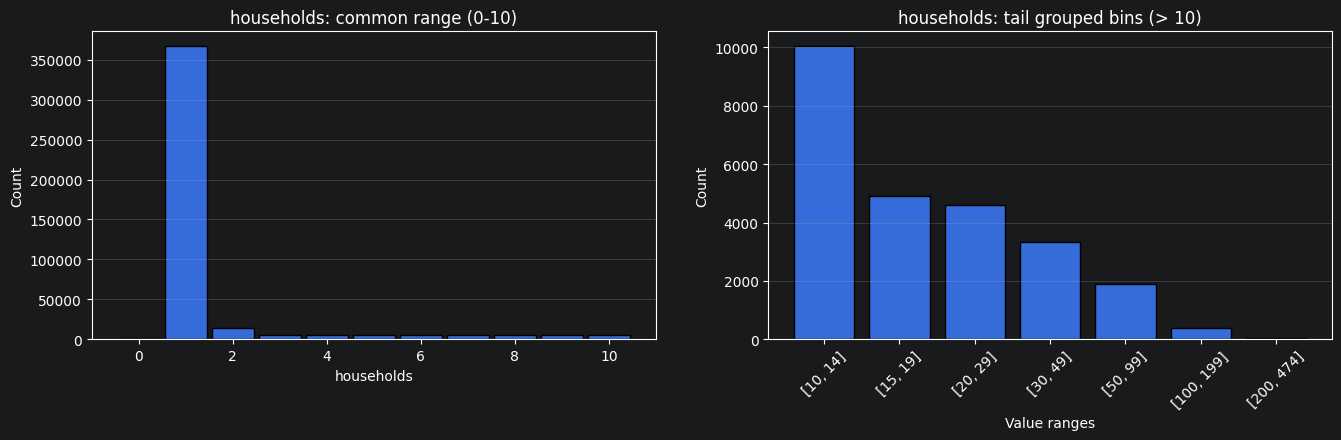

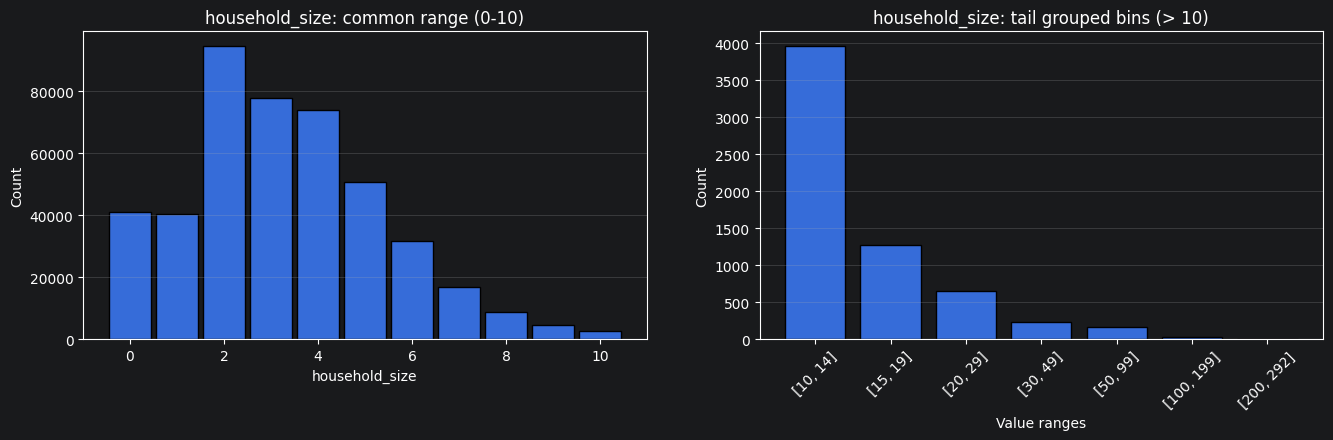

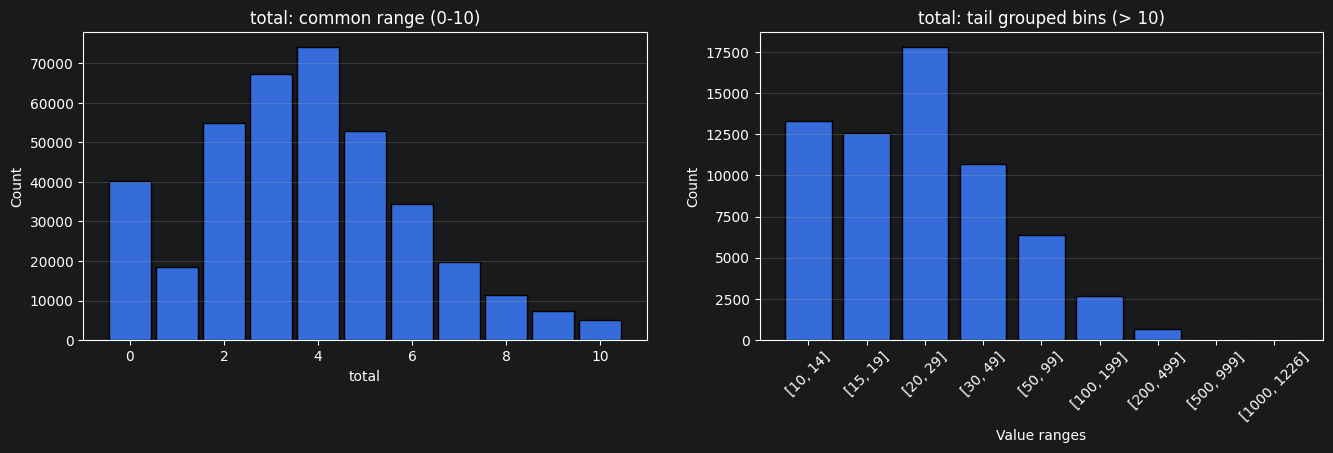

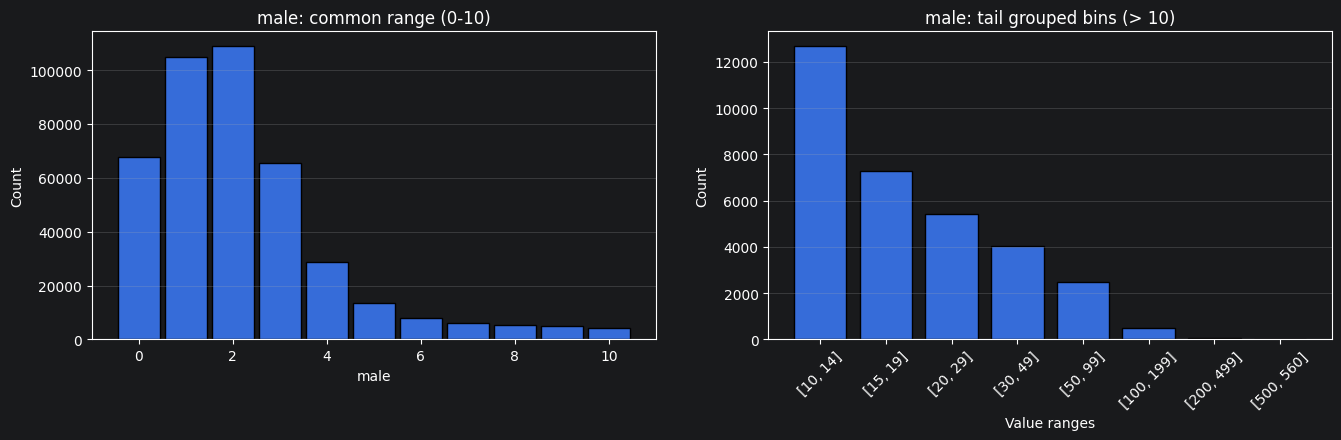

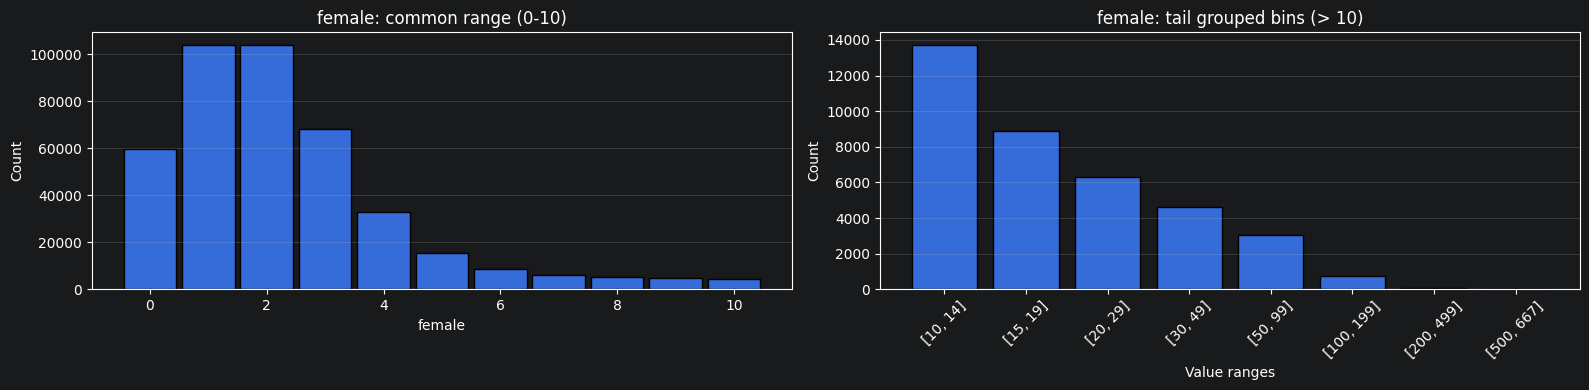

In [68]:
numerical_columns = ['households', 'household_size', 'total', 'male', 'female']
for col in numerical_columns:
    s = df_population[col]
    cutoff = 10

    negative_count = (s < 0).sum()
    non_integer_count = (s % 1 != 0).sum()
    max_value = s.max()

    print(f"{col}:")
    print(f"  negative values: {negative_count}")
    print(f"  non-integer values: {non_integer_count}")
    print(f"  maximum value: {max_value}")

    if non_integer_count > 0:
        s = np.floor(s).astype('Int64')

    counts = s.value_counts().sort_index()
    common_counts = counts.reindex(range(0, cutoff + 1), fill_value=0)
    tail_values = s[s > cutoff]

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    axes[0].bar(common_counts.index, common_counts.values, edgecolor='black', width=0.9)
    axes[0].set_title(f'{col}: common range (0-{cutoff})')
    axes[0].set_xlabel(f'{col}')
    axes[0].set_ylabel('Count')
    axes[0].grid(axis='y', alpha=0.3)
    print(common_counts)

    if tail_values.empty:
        axes[1].text(0.5, 0.5, f'No values > {cutoff}', ha='center', va='center')
        axes[1].set_title(f'{col}: tail grouped bins (> {cutoff})')
        axes[1].set_xticks([])
        axes[1].set_yticks([])
    else:
        max_tail = int(tail_values.max())
        candidate_edges = [cutoff, 15, 20, 30, 50, 100, 200, 500, 1000]
        edges = sorted(set([cutoff] + [e for e in candidate_edges if cutoff < e < max_tail] + [max_tail + 1]))
        tail_bins = pd.cut(tail_values, bins=edges, right=False)
        tail_counts = tail_bins.value_counts().sort_index()
        labels = [f'[{int(interval.left)}, {int(interval.right) - 1}]' for interval in tail_counts.index]
        axes[1].bar(labels, tail_counts.values, edgecolor='black')
        axes[1].set_title(f'{col}: tail grouped bins (> {cutoff})')
        axes[1].set_xlabel('Value ranges')
        axes[1].set_ylabel('Count')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(axis='y', alpha=0.3)
        print(tail_counts)
        print("\n")

plt.tight_layout()
plt.show()

In [73]:
for col in numerical_columns:
    print(f"{col} skewness: {df_population[col].skew():.2f}")
    print(f"{col} kurtosis: {df_population[col].kurt():.2f}")

households skewness: 12.05
households kurtosis: 292.29
household_size skewness: 17.56
household_size kurtosis: 875.04
total skewness: 11.61
total kurtosis: 283.48
male skewness: 11.22
male kurtosis: 267.74
female skewness: 11.69
female kurtosis: 284.77


Similarly to `df_buildings`, extreme values of numerical columns are plausible and expected, given that the dataframe mixes houses with single and multiple households.

### Snowflake

In [84]:
from src.connectors import get_snowflake_connection

In [88]:
def query(sql, fetch='pandas'):
    with get_snowflake_connection() as connection:
        with connection.cursor() as cursor:
            cursor.execute(sql)
            if fetch == 'pandas':
                return cursor.fetch_pandas_all()
            elif fetch == 'one':
                return cursor.fetchone()

In [96]:
df = query("SELECT * FROM RECRUITMENT_TRACES LIMIT 100")

In [97]:
df

,OCCURED_AT,APP_ID,PROXI_USER_ID,LATITUDE,LONGITUDE,GEOHASH,PAIRING_ID,MAC_ADDRESS,RSSI
0,2020-07-05 10:41:20.694,173aa517-166e-4ef2-a154-e2b47d6c424a,cc551ae2-bf2f-4bee-888d-0bd02de84484,52.746048,14.704514,u36knd5,HUAWEI-B311-DA94,d4:62:ea:56:da:94,-59
1,2020-07-06 19:35:17.023999,5ff6f9c4-b524-487c-ac44-fe677f05ec43,bbd58f7c-782a-41b1-8426-552438d4423c,51.124277,17.033443,u3h4gdgk,2.4G-Dawno-nie-pilem-piwa,54:a6:5c:4f:58:7d,-83
2,2020-07-07 08:25:56.730999,5ff6f9c4-b524-487c-ac44-fe677f05ec43,98884a67-2687-451b-9074-14f2e4094035,None,None,None,NETIASPOT-C45AF0,00:12:2a:c4:5a:f8,-72
3,2020-07-07 05:33:56.177999,5ff6f9c4-b524-487c-ac44-fe677f05ec43,a9dd8b17-0ed0-44c4-a155-0dde84b8881c,None,None,None,DonSamadhi,74:f8:db:6f:a2:b2,-81
4,2020-07-07 07:32:12.595,248e95ba-ba2d-496b-8dc5-57cc5ff2ef57,259fc1b5-4dc8-4b87-8d15-16ff7fca2729,54.367132,18.625774,u3tjrc4z,DIRECT-EF-HP Ink Tank Wireless,e4:e7:49:d7:be:f0,-87
...,...,...,...,...,...,...,...,...,...
95,2020-07-07 07:38:17.467,5ff6f9c4-b524-487c-ac44-fe677f05ec43,641b1620-fb96-4f0f-addd-2721fb1b86cb,None,None,None,Internet_Domowy_276D4D,34:ba:9a:27:6d:4d,-89
96,2020-07-07 09:02:41.035,5ff6f9c4-b524-487c-ac44-fe677f05ec43,37a038b1-e231-44d7-af09-d16b8fbe7611,None,None,None,TROJAN_1,98:da:c4:eb:d8:c4,-86
97,2020-07-07 09:02:32.986,5ff6f9c4-b524-487c-ac44-fe677f05ec43,84ae8f8d-6d41-4f92-a0c0-7470437ebd5b,None,None,None,UPC Wi-Free #SprawdzUPCMobile!,56:67:11:bb:9b:05,-88
98,2020-07-07 08:30:12.164,5ff6f9c4-b524-487c-ac44-fe677f05ec43,91bc3514-5f3e-41b1-bc9b-60419bb72ffc,None,None,None,Mediaexpert,60:31:97:f9:23:ef,-77


In [103]:
count1 = query("SELECT COUNT(*) FROM RECRUITMENT_TRACES", fetch='one')

In [104]:
print(f"Number of traces: {count1[0]:,}")

Number of traces: 435,591,908


In [115]:
ANALYSIS_BBOX

{'lng_min': 18.54, 'lat_min': 49.96, 'lng_max': 20.12, 'lat_max': 50.48}

In [129]:
BBOX_FILTER = f"""
    CAST(latitude AS FLOAT) BETWEEN {ANALYSIS_BBOX['lat_min']} AND {ANALYSIS_BBOX['lat_max']}
    AND CAST(longitude AS FLOAT) BETWEEN {ANALYSIS_BBOX['lng_min']} AND {ANALYSIS_BBOX['lng_max']}
"""

In [130]:
count2 = query(f"""
        SELECT COUNT(*) FROM RECRUITMENT_TRACES
        WHERE {BBOX_FILTER}
        """, fetch='one')

In [131]:
print(f"Number of traces inside our analysis area: {count2[0]:,}")

Number of traces inside our analysis area: 12,506,636


In [133]:
count3 = query(f"""
        SELECT COUNT(DISTINCT proxi_user_id) FROM RECRUITMENT_TRACES
        WHERE {BBOX_FILTER}
        """, fetch='one')

In [139]:
print(f"Number of unique users inside our analysis area: {count3[0]:,}")
print(f"Average number of generated signals per user: {count2[0]/count3[0]}")

Number of unique users inside our analysis area: 90,702
Average number of generated signals per user: 137.88710282022447
